# PyDoseRT example for deep learning-based direct machine-parameter prediction

**Author:** Attila Simkó

In this toy example we show how PyDoseRT can be incorporated into a deep learning workflow. 

1. Load a sample input volume and pretrained model weights,
2. Design a model that performs dose prediction with PyDoseRT as a final layer.
3. Convert the prediction into a beam sequence,
4. Visualize the predicted dose.

Incorporating the dose engine into a deep learning model means the final model output will be a dose distribution. This turns our problem into dose prediction. 

However training this dose prediction model will inherently learn the machine parameters as well, that are a direct intermediate output of the model. It enables dose-based learning without losing interpretability, and with regularization terms, we can also easily ensure machine deliverability.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import torch
import numpy as np
from pathlib import Path
import time
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
import urllib.request

from pydosert.utils.plotting import overlay_mask_outline
from pydosert.physics.attenuation.hu_density_conversion import convert_HU_to_density
import pydosert as PDRT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

pydosert is already installed


## Load a reference sample and pretrained weights

We use two files from the PyDoseRT example repository:

- one sample input tensor,
- one set of pretrained model weights.

The training process is purposefully not described in this workflow, as it will be part of a later publication. Some limitations of the current model is having only 60 beams/control points, not having regularization terms on the MLC positions, and completely ignoring the jaw positions for simplicity. All this, and more will be included in the publication.

In [2]:
url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/dlmodel_sample.npz"
local_data_path = Path("data/dlmodel_sample.npz")

# Make sure the folder exists
local_data_path.parent.mkdir(parents=True, exist_ok=True)

# Download only if the file is missing
if not local_data_path.exists():
    urllib.request.urlretrieve(url, local_data_path)
else:
    print(f"{local_data_path} already exists, skipping download.")

input_array = torch.from_numpy(np.expand_dims(np.load(local_data_path)["input_array"], 0))

data/dlmodel_sample.npz already exists, skipping download.


In [3]:
url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/dlmodel_weights.pt"
local_weight_path = Path("data/dlmodel_weights.pt")

# Make sure the folder exists
local_weight_path.parent.mkdir(parents=True, exist_ok=True)

# Download only if the file is missing
if not local_weight_path.exists():
    urllib.request.urlretrieve(url, local_weight_path)
else:
    print(f"{local_weight_path} already exists, skipping download.")

data/dlmodel_weights.pt already exists, skipping download.


## Define the prediction model

The model takes a compact anatomical input and predicts beam-related quantities for a fixed 60-beam configuration.

In this toy example, the network predicts:

- MLC leaf positions,
- monitor units,
- jaw positions,
- a PyDoseRT-calculated dose from the machine parameters, used for dose-based training.

The architecture below is included directly in the notebook so the example is self-contained. Some limitations of the current model are described above.

In [4]:


def make_ordered_pairs(x: torch.Tensor, min_gap: float = 0.0) -> torch.Tensor:
    """
    x: [..., 2]
    Interprets:
      x[..., 0] = center
      x[..., 1] = raw width parameter

    Returns:
      ordered pairs [..., 2] where:
        left  = center - width/2
        right = center + width/2
      and width >= min_gap
    """
    center = (100 * torch.sigmoid(x[..., 0])) - 50
    width = min_gap + ((100 - min_gap) * torch.sigmoid(x[..., 1]))

    left = center - 0.5 * width
    right = center + 0.5 * width

    return torch.stack([left, right], dim=-1)

class ConvBlock3D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(d_model)
        self.norm_kv = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.norm_ff = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
        )

    def forward(self, q: torch.Tensor, kv: torch.Tensor) -> torch.Tensor:
        q2 = self.norm_q(q)
        kv2 = self.norm_kv(kv)
        attn_out, _ = self.cross_attn(q2, kv2, kv2, need_weights=False)
        q = q + attn_out
        q = q + self.ff(self.norm_ff(q))
        return q


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x2 = self.norm1(x)
        attn_out, _ = self.attn(x2, x2, x2, need_weights=False)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


class FastBeamLeafNet(nn.Module):
    """
    CNN encoder + beam-query decoder

    Input:
        x: [B, C, D, H, W]

    Outputs:
        y1: [B, num_beams, num_leafs, 2]   leaf positions
        y2: [B, num_beams]                 monitor units
        y3: [B, num_beams, 2]              jaw positions
        dose: [B, D, H, W]
    """

    def __init__(
        self,
        in_channels: int = 8,
        num_beams: int = 12,
        num_leafs: int = 80,
        base_channels: int = 24,
        d_model: int = 192,
        nhead: int = 4,
        num_beam_layers: int = 2,
        num_leaf_layers: int = 1,
        dropout: float = 0.1,
        memory_tokens_shape=(3, 4, 4),  # low-res token grid, keeps attention cheap
        machine_config=None,
        dtype=torch.float32,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    ):
        super().__init__()

        self.num_beams = num_beams
        self.num_leafs = num_leafs
        self.d_model = d_model
        self.memory_tokens_shape = memory_tokens_shape

        # -------------------------
        # 3D CNN encoder
        # -------------------------
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, base_channels, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm3d(base_channels),
            nn.GELU(),
        )
        # [256,256,88] -> [128,128,44]

        self.enc1 = ConvBlock3D(base_channels, base_channels * 2, stride=2)   # -> [64,64,22]
        self.enc2 = ConvBlock3D(base_channels * 2, base_channels * 4, stride=2)  # -> [32,32,11]
        self.enc3 = ConvBlock3D(base_channels * 4, base_channels * 8, stride=2)  # -> [16,16,6]

        feat_dim = base_channels * 8

        self.memory_pool = nn.AdaptiveAvgPool3d(memory_tokens_shape)
        self.memory_proj = nn.Conv3d(feat_dim, d_model, kernel_size=1, bias=False)

        # -------------------------
        # Positional embeddings for memory tokens
        # -------------------------
        num_memory_tokens = memory_tokens_shape[0] * memory_tokens_shape[1] * memory_tokens_shape[2]
        self.memory_pos = nn.Parameter(torch.randn(1, num_memory_tokens, d_model) * 0.02)

        # -------------------------
        # Beam queries
        # -------------------------
        self.beam_query_embed = nn.Parameter(torch.randn(1, num_beams, d_model) * 0.02)
        self.beam_index_embed = nn.Parameter(torch.randn(1, num_beams, d_model) * 0.02)

        # Fixed gantry-angle embedding projected to d_model
        gantry_angles = torch.linspace(0, 2 * math.pi, num_beams + 1)[:-1]
        gantry_feat = torch.stack(
            [torch.sin(gantry_angles), torch.cos(gantry_angles)],
            dim=-1
        )  # [num_beams, 2]
        self.register_buffer("gantry_feat", gantry_feat, persistent=False)
        self.gantry_proj = nn.Linear(2, d_model)

        # -------------------------
        # Beam decoder
        # -------------------------
        self.beam_cross_blocks = nn.ModuleList([
            CrossAttentionBlock(d_model=d_model, nhead=nhead, dropout=dropout)
            for _ in range(num_beam_layers)
        ])
        self.beam_self_blocks = nn.ModuleList([
            SelfAttentionBlock(d_model=d_model, nhead=nhead, dropout=dropout)
            for _ in range(num_beam_layers)
        ])

        # -------------------------
        # Heads from beam tokens
        # -------------------------
        self.mu_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 1),
        )

        self.jaw_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 2),
        )

        # -------------------------
        # Leaf decoder
        # -------------------------
        self.leaf_query_embed = nn.Parameter(torch.randn(1, num_leafs, d_model) * 0.02)
        self.leaf_index_embed = nn.Parameter(torch.randn(1, num_leafs, d_model) * 0.02)

        self.leaf_self_blocks = nn.ModuleList([
            SelfAttentionBlock(d_model=d_model, nhead=nhead, dropout=dropout)
            for _ in range(num_leaf_layers)
        ])

        self.leaf_cross_blocks = nn.ModuleList([
            CrossAttentionBlock(d_model=d_model, nhead=nhead, dropout=dropout)
            for _ in range(num_leaf_layers)
        ])

        self.leaf_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, 2),
        )

        # Optional tiny beam->leaf conditioning
        self.beam_to_leaf = nn.Linear(d_model, d_model)

        # -------------------------
        # Physics engine setup
        # -------------------------
        beam_sequence = PDRT.BeamSequence.from_tensors(
            leaf_positions=torch.zeros((num_beams, num_leafs, 2), dtype=torch.float32, device=device),
            mus=torch.zeros(num_beams, dtype=torch.float32, device=device),
            jaw_positions=torch.zeros((num_beams, 2), dtype=torch.float32, device=device),
            gantry_angles=torch.from_numpy(np.linspace(0, 2 * np.pi, num_beams, endpoint=False)),
            collimator_angles=torch.from_numpy(np.zeros(num_beams, dtype=np.float32)),
            iso_center=torch.from_numpy(np.array([200, 200, 200])),
            sid=1000.0,
            field_size=(400, 400)
        )
        beam_sequence = beam_sequence.to(device)
        beam_sequence = beam_sequence.to(dtype)

        self.engine = PDRT.DoseEngine(
            machine_config=machine_config,
            dose_grid_spacing=(4.5, 1.5625, 1.5625),
            dose_grid_shape=(88, 256, 256),
            beam_template=beam_sequence,
            kernel_size=15,
            dtype=torch.float32,
            device=device
        )
        self.engine.calibrate(machine_config.calibration_mu, beam_sequence)
        self.dtype = dtype
        self.device = device

    def encode_volume(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.memory_pool(x)       # [B, C, Dm, Hm, Wm]
        x = self.memory_proj(x)       # [B, d_model, Dm, Hm, Wm]
        x = x.flatten(2).transpose(1, 2)  # [B, T, d_model]
        x = x + self.memory_pos
        return x

    def decode_beams(self, memory: torch.Tensor, batch_size: int) -> torch.Tensor:
        beam_q = self.beam_query_embed.expand(batch_size, -1, -1)
        beam_q = beam_q + self.beam_index_embed

        gantry_emb = self.gantry_proj(self.gantry_feat).unsqueeze(0)  # [1, num_beams, d_model]
        beam_q = beam_q + gantry_emb

        for cross_block, self_block in zip(self.beam_cross_blocks, self.beam_self_blocks):
            beam_q = cross_block(beam_q, memory)
            beam_q = self_block(beam_q)

        return beam_q  # [B, num_beams, d_model]

    def decode_leaves(self, beam_tokens: torch.Tensor) -> torch.Tensor:
        """
        beam_tokens: [B, num_beams, d_model]
        returns raw leaf params: [B, num_beams, num_leafs, 2]
        """
        B, Nb, D = beam_tokens.shape

        leaf_q = self.leaf_query_embed + self.leaf_index_embed  # [1, L, D]
        leaf_q = leaf_q.expand(B * Nb, -1, -1)                  # [B*Nb, L, D]

        beam_cond = self.beam_to_leaf(beam_tokens).reshape(B * Nb, 1, D)
        leaf_tokens = leaf_q + beam_cond
        
        for self_block, cross_block in zip(
            self.leaf_self_blocks,
            self.leaf_cross_blocks,
        ):
            leaf_tokens = self_block(leaf_tokens)
            leaf_tokens = cross_block(leaf_tokens, beam_cond)

        leaf_raw = self.leaf_head(leaf_tokens)  # [B*Nb, L, 2]
        leaf_raw = leaf_raw.view(B, Nb, self.num_leafs, 2)
        return leaf_raw

    def forward(self, x):
        ct = convert_HU_to_density(1000 * x[:, 0, ...])
        # ext_mask = x[:, -1, ...]

        start_time = time.time()

        memory = self.encode_volume(x)
        B = x.shape[0]

        beam_tokens = self.decode_beams(memory, B)

        # Beam-level heads
        y2_raw = self.mu_head(beam_tokens).squeeze(-1)   # [B, num_beams]
        y3_raw = self.jaw_head(beam_tokens)              # [B, num_beams, 2]

        # Leaf-level decoding
        y1_raw = self.decode_leaves(beam_tokens)         # [B, num_beams, num_leafs, 2]

        # Output parameterization
        y1 = make_ordered_pairs(y1_raw, min_gap=1.0)
        y2 = (100.0 / self.num_beams) + (F.softplus(y2_raw) * (42.7 * 100.0 / self.num_beams))
        y3 = make_ordered_pairs(y3_raw, min_gap=1.0)

        print(f"Machine parameter prediction in: {np.round(1000*(time.time() - start_time))}ms")
        start_time = time.time()

        dose = self.engine.forward(y1, y2, None, density_image=ct)
        print(f"Additional dose calculation in: {np.round(1000*(time.time() - start_time))}ms")
        return y1, y2, y3, dose

## Initialize the model

Next, we create the machine configuration and instantiate the pretrained network.

The beam setup here uses **60 beams**, matching the output layout of the toy model.

In [5]:
preset_path = Path(pydosert.data.__file__).parent / "machine_presets" / "dlmodel_10MV.json"
machine_config = PDRT.MachineConfig(
    preset=str(preset_path)
  )
model = FastBeamLeafNet(
    in_channels=4,
    num_beams=60,
    num_leafs=60,
    base_channels=12,
    d_model=128,
    nhead=4,
    num_beam_layers=2,
    num_leaf_layers=3,
    dropout=0.0,
    memory_tokens_shape=(4, 6, 6),
    machine_config=machine_config,
    dtype=dtype,
    device=device,
)

checkpoint = torch.load(
    local_weight_path,
    map_location="cuda",
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

Calibration failed. Adjusting calibration factor to: 0.0031006410013647953


<All keys matched successfully>

## Load the example input

The sample input contains the image and structure information used by the model during inference. Below we visualize a few example slices.

Text(0.5, 1.0, 'External contour')

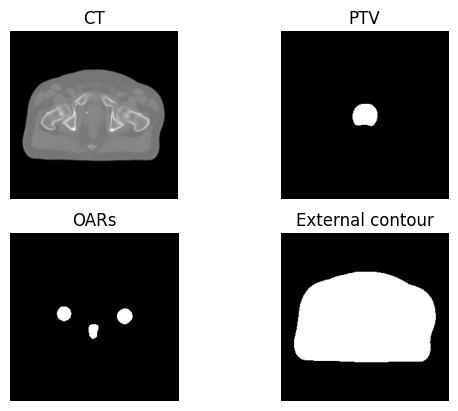

In [6]:
plt.subplot(221)
plt.imshow(input_array[0, 0, 44, :, :], cmap='gray')
plt.axis('off')
plt.title("CT")

plt.subplot(222)
plt.imshow(input_array[0, 1, 44, :, :], cmap='gray')
plt.axis('off')
plt.title("PTV")

plt.subplot(223)
plt.imshow(input_array[0, 2, 44, :, :], cmap='gray')
plt.axis('off')
plt.title("OARs")

plt.subplot(224)
plt.imshow(input_array[0, 3, 44, :, :], cmap='gray')
plt.axis('off')
plt.title("External contour")

## Predict machine parameters

We now run the model in inference mode.

The worflow has been inspired by a (recent publication)[https://arxiv.org/abs/2603.06338] claiming to achieve machine parameter prediction under a second. This, naturally, cannot be validated as their code is not public. The authors have also decided to describe PyDoseRT in a rather negative way, which lead us to publish this toy-example of using PyDoseRT for machine parameter prediction .

In this example, the network predicts machine parameters for a **60-beam** setup in about **7ms**. The dose prediction is only necessary for dose-based training, not for inference, so the processing times of PyDoseRT are not relevant in this application.

**The code and model weights are public.**

A more mature version of this model will be part of a future publication, with a **180-beam** setup having inference times of under **4ms**.


In [7]:
input_array = input_array.to(device).to(dtype)
model = model.to(device).to(dtype)

with torch.no_grad():
    pred_leafs, pred_mus, pred_jaws, pred_dose = model(input_array)

Machine parameter prediction in: 64.0ms
Additional dose calculation in: 91.0ms


## Convert the prediction to a beam sequence

The predicted leaf positions and monitor units can be assembled into a PyDoseRT `BeamSequence`.

In this toy example, jaw positions are included in the prediction output, but they are not yet used as part of the planning workflow.

This `BeamSequence` can be exported into an RTPLAN and imported into a TPS for further evaluations if necessary.

In [8]:
pred_beam_sequence = PDRT.BeamSequence.from_tensors(
    leaf_positions=pred_leafs[0, ...],
    mus=pred_mus[0, ...],
    jaw_positions=pred_jaws[0, ...],
    gantry_angles=torch.from_numpy(np.linspace(0, 2 * np.pi, model.num_beams, endpoint=False)),
    collimator_angles=torch.from_numpy(np.zeros(model.num_beams, dtype=np.float32)),
    iso_center=torch.from_numpy(np.array([200, 200, 200])),
    sid=1000.0,
    field_size=(400, 400)
)

## Visualize the predicted dose

Finally, we inspect the predicted dose in axial, coronal, and sagittal views.

This is only a qualitative visualization step. In a more complete workflow, additional deliverability-aware losses and validation steps would be added during training and evaluation.

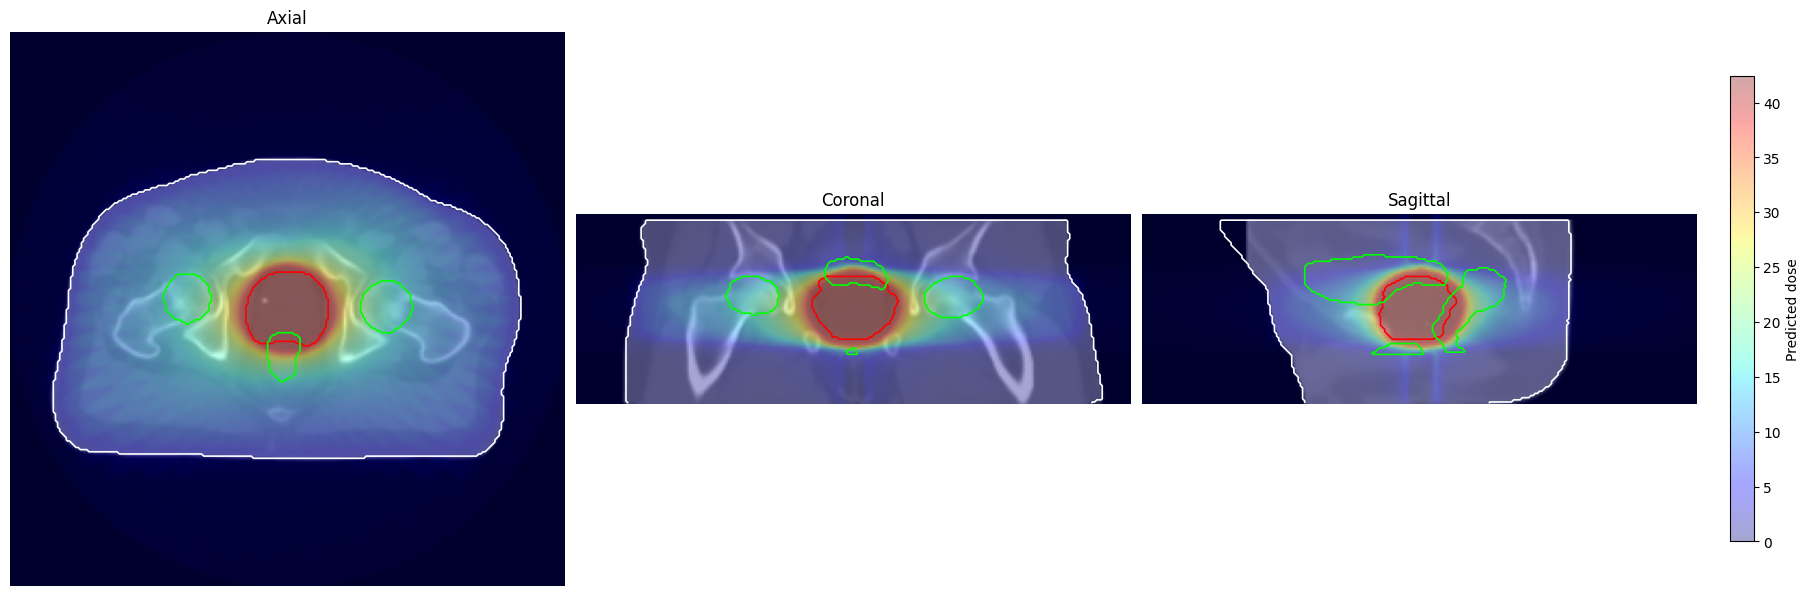

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def to_np(x):
    return x.detach().cpu().numpy()

def draw_outlines(ax, masks, colors=('r', 'lime', 'w')):
    for m, c in zip(masks, colors):
        ax.contour(m.astype(float), levels=[0.5], colors=c, linewidths=1.2)

# --- slices ---
axial_ct   = to_np(input_array[0, 0, 44, :, :])
axial_dose = to_np(pred_dose[0, 44, :, :])
axial_masks = [
    to_np(input_array[0, 1, 44, :, :]),
    to_np(input_array[0, 2, 44, :, :]),
    to_np(input_array[0, 3, 44, :, :]),
]

cor_ct   = np.flipud(to_np(input_array[0, 0, :, 128, :]))
cor_dose = np.flipud(to_np(pred_dose[0, :, 128, :]))
cor_masks = [
    np.flipud(to_np(input_array[0, 1, :, 128, :])),
    np.flipud(to_np(input_array[0, 2, :, 128, :])),
    np.flipud(to_np(input_array[0, 3, :, 128, :])),
]

sag_ct   = np.flipud(to_np(input_array[0, 0, :, :, 128]))
sag_dose = np.flipud(to_np(pred_dose[0, :, :, 128]))
sag_masks = [
    np.flipud(to_np(input_array[0, 1, :, :, 128])),
    np.flipud(to_np(input_array[0, 2, :, :, 128])),
    np.flipud(to_np(input_array[0, 3, :, :, 128])),
]

dose_vmin = 0
dose_vmax = to_np(pred_dose[0]).max()

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

views = [
    (axes[0], axial_ct, axial_dose, axial_masks, 'Axial'),
    (axes[1], cor_ct, cor_dose, cor_masks, 'Coronal'),
    (axes[2], sag_ct, sag_dose, sag_masks, 'Sagittal'),
]

for ax, ct, dose, masks, title in views:
    ax.imshow(ct, cmap='gray')
    im = ax.imshow(dose, cmap='jet', alpha=0.35, vmin=dose_vmin, vmax=dose_vmax)
    draw_outlines(ax, masks)
    ax.set_title(title)
    ax.axis('off')

cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Predicted dose')

plt.show()

## Summary

This toy example shows how a pretrained model can predict beam-related machine parameters for a fixed 60-beam configuration very quickly.

Jaw positions are not yet used, and additional loss functions for plan deliverability will be incorporated in future versions together with a more fully optimized training pipeline.